In [12]:
# ===== 기본 세트 (거의 항상 필요) =====
import pandas as pd                    # 데이터프레임 다루기 (표 형태 데이터 처리)
import numpy as np                     # 수치 계산, 배열 연산
import matplotlib.pyplot as plt        # 기본 시각화
import seaborn as sns                  # matplotlib 기반의, 더 예쁘고 간결한 통계 시각화

# ===== 파일/경로/시스템 =====
import os                              # 파일 경로 확인, 파일 존재 여부(os.path.exists) 등
from pathlib import Path               # 폴더/파일 경로를 객체로 다루기 (work_dir / "파일명")
import joblib                          # 학습된 scaler/encoder를 파일로 저장하고 재사용
import platform                        # OS 종류 확인 (Windows/Mac/Linux 구분 필요할 때)
import warnings                        # 경고 메시지 제어(숨기기/표시)

# ===== 벤치마크/성능 측정 =====
import time                            # 코드 실행 시간 측정 (time.perf_counter())
import psutil                          # 메모리 사용량 측정 (rss_mb 등)
import gc                              # 메모리 강제 정리(garbage collection)

# ===== 결측치 탐색 시각화 =====
import missingno as msno               # 결측치 위치(matrix), 관계(heatmap) 시각화

# ===== 인터랙티브 시각화 =====
import plotly.express as px            # 마우스 hover/zoom 가능한 인터랙티브 그래프
import plotly.io as pio                 # plotly 렌더러(출력 방식) 설정

# ===== 대용량 데이터 처리 =====
import polars as pl                     # pandas보다 빠른 대용량 데이터 처리 (Rust 기반)

# ===== 통계 검증 =====
import statsmodels.api as sm            # 회귀분석, 다중공선성(Cond. No.) 등 통계 검증
from scipy import stats

# ===== 한글 폰트 설정 =====
import matplotlib.font_manager as fm    # 그래프에 한글 폰트 적용 시 필요
import matplotlib.pyplot as plt

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# ===== 인코딩/스케일링/모델링 (sklearn) =====
from sklearn.preprocessing import LabelEncoder      # 카테고리를 숫자로 변환 (순서형)
from sklearn.preprocessing import MinMaxScaler       # 0~1 범위로 스케일링
from sklearn.preprocessing import StandardScaler     # 평균0, 표준편차1로 스케일링
from sklearn.preprocessing import RobustScaler       # 이상치에 강한 스케일링 (median/IQR 기반)
from sklearn.linear_model import LinearRegression    # 선형 회귀 모델
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀(분류) 모델
from sklearn.ensemble import RandomForestRegressor   # 랜덤포레스트(트리 기반) 모델
from sklearn.metrics import roc_auc_score, log_loss  # 분류 모델 평가지표

In [5]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


In [ ]:
# [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 실제 확률은 10%이다.
# H₁ (대립가설): 실제 확률은 10%보다 낮다.

In [6]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?

result = stats.binomtest(x, n, p, alternative='less')

print(f"p-value: {result.pvalue:.4f}")

p-value: 0.0320


In [10]:
# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

alpha = 0.05

if result.pvalue < alpha:
    print(f"p-value({result.pvalue:.4f}) < 유의수준({alpha})")
    print("→ 귀무가설을 기각합니다. '성공 확률이 10% 보다 낮다'는 주장이 통계적으로 유의합니다.")
else:
    print(f"p-value({result.pvalue:.4f}) >= 유의수준({alpha})")
    print("→ 귀무가설을 기각할 수 없습니다. 통계적으로 유의한 차이를 발견하지 못했습니다.")

p-value(0.0320) < 유의수준(0.05)
→ 귀무가설을 기각합니다. '성공 확률이 10% 보다 낮다'는 주장이 통계적으로 유의합니다.


In [8]:
# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.

np.random.seed(42)   # 재현성을 위해 (선택사항)

n = 200        # 시행 횟수
p_null = 0.1   # 귀무가설의 성공 확률
n_simulations = 10000   # 시뮬레이션 반복 횟수

simulated_successes = np.random.binomial(n=n, p=p_null, size=n_simulations)

print(f"시뮬레이션 결과 개수: {len(simulated_successes)}개")
print(f"처음 10개: {simulated_successes[:10]}")
print(f"시뮬레이션 평균: {simulated_successes.mean():.2f} (이론값: {n*p_null})")

시뮬레이션 결과 개수: 10000개
처음 10개: [19 27 23 21 16 16 14 25 21 22]
시뮬레이션 평균: 19.91 (이론값: 20.0)


In [9]:
empirical_p_value = (simulated_successes <= 12).mean()
print(f"시뮬레이션 기반 p-value: {empirical_p_value:.4f}")
print(f"scipy.stats 기반 p-value: 0.0320 (Q2에서 계산한 값)")

시뮬레이션 기반 p-value: 0.0313
scipy.stats 기반 p-value: 0.0320 (Q2에서 계산한 값)


🧠 데이터를 어떻게 읽을까요?
Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요?
▸ p-value: 0.0320으로 귀무가설을 기각합니다. '성공 확률이 10% 보다 낮다'는 주장이 통계적으로 유의합니다.

시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요?
▸ 개발사의 주장은 확률이 10%라는 주장이기 때문에 우리가 관찰한 12회 성공은 개발사의 주장 기준에서는 드문 일이다.

이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요?
▸ 귀무가설 즉 개발사에서 주장한 10%의 확률이 맞다는 가설을 기준으로 p-값은 내가 말한 10% 보다 낮다고 가정한 상황이 발생할 확률에 해당해 그래서 실제 분석 결과 p-값이 낮게 나온다면 귀무가설의 기준인 10%라는 가설이 아닌 10% 아니라는 가설의 힘이 실리게 되는거고 귀무가설을 기각, 대립가설을 지지하게 되는거지

만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요?
▸ 횟수를 늘린다면 p값이 더 낮게 측정될 것이다.

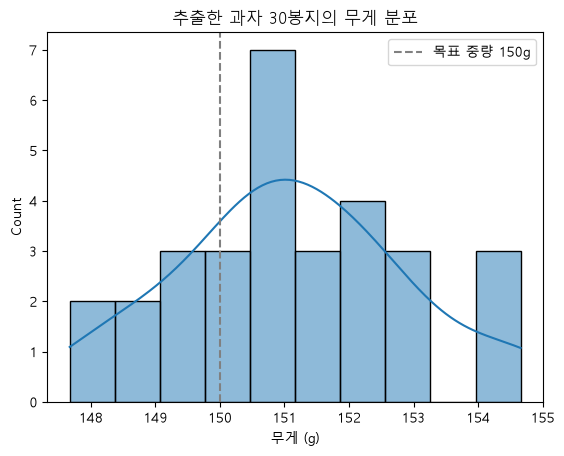

In [13]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

In [ ]:
# [문제 2] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 과자 한 봉지의 중량은 150g이다.
# H₁ (대립가설): 과자 한 봉지의 중량은 150g이 아니다.

In [14]:
# [문제 2] Q2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

t_stat, p_value = stats.ttest_1samp(sample_weights, pop_mean)

print(f"t-통계량: {t_stat:.4f}")
print(f"p-값: {p_value:.4f}")

t-통계량: 3.4193
p-값: 0.0019


In [18]:
# [문제 2] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

alpha = 0.05

if p_value < alpha:
    print(f"p-value({p_value:.4f}) < 유의수준({alpha})")
    print("→ 귀무가설을 기각합니다. '150g'이 아니라는 주장이 통계적으로 유의합니다.")
else:
    print(f"p-value({p_value:.4f}) >= 유의수준({alpha})")
    print("→ 귀무가설을 기각할 수 없습니다. 통계적으로 유의한 차이를 발견하지 못했습니다.")

p-value(0.0019) < 유의수준(0.05)
→ 귀무가설을 기각합니다. '150g'이 아니라는 주장이 통계적으로 유의합니다.


In [16]:
# [문제 2] Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균을 리스트에 저장해봅시다.
# 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.

sample_std = sample_weights.std(ddof=1)   # 우리 표본의 표준편차 사용
n = 30
n_simulations = 10000

simulated_means = []   # 결과를 쌓아둘 빈 리스트

for i in range(n_simulations):
    simulated_sample = np.random.normal(loc=pop_mean, scale=sample_std, size=n)   # H0(평균=150)이 사실이라 가정
    simulated_means.append(simulated_sample.mean())

print(f"총 {len(simulated_means)}개의 시뮬레이션 표본 평균이 저장되었습니다")
print(simulated_means[:5])

총 10000개의 시뮬레이션 표본 평균이 저장되었습니다
[np.float64(149.7819059959582), np.float64(150.02319275608127), np.float64(149.96354681186995), np.float64(149.82907417136227), np.float64(150.50181950265096)]


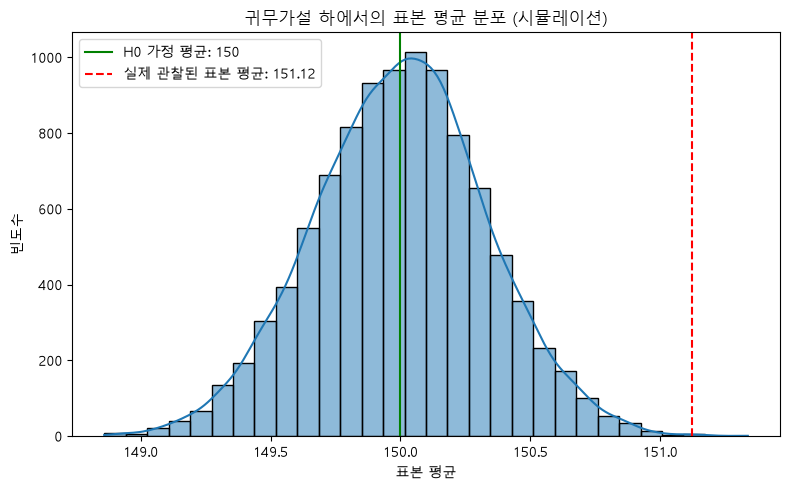

In [17]:
# [문제 2] Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.

observed_mean = sample_weights.mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(simulated_means, bins=30, kde=True, ax=ax)

ax.axvline(pop_mean, color="green", linestyle="-", label=f"H0 가정 평균: {pop_mean}")
ax.axvline(observed_mean, color="red", linestyle="--", label=f"실제 관찰된 표본 평균: {observed_mean:.2f}")

ax.set_title("귀무가설 하에서의 표본 평균 분포 (시뮬레이션)")
ax.set_xlabel("표본 평균")
ax.set_ylabel("빈도수")
ax.legend()
plt.tight_layout()
plt.show()

🧠 데이터를 어떻게 읽을까요?
Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리)
▸ 히트토그램은 정규분포의 종 모양과 비슷해졌고 표본이 n>=30에 해당하여 중심극한정리에 따라 정규분포의 모양에 가까워졌다.

우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요?
▸ 정규분포 상에서 양쪽 끝에 위치하는 드물게 나타나는 곳에 위치한다.

만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요?
▸ 기존 0.019보다 더 오른쪽에 위치한다.

이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?)
▸ 150g이라는 귀무가설이 기각되고 150g이 아니라는 대립가설이 지지를 받고 실제 평균이 150g보다 더 높게 관측되므로 공장에서는 품질관리 QC를 더 철저하게 진행하고 150g보다 더 많게 과자가 포장되면 그만큼 공장에서는 비용적인 손해가 발생하게 된다.

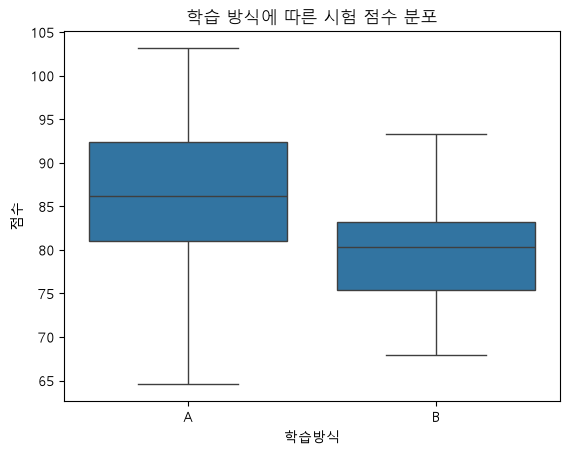

In [19]:
# 데이터 생성 (두 학습 방식의 시험 점수)
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

df_scores = pd.DataFrame({'점수': np.concatenate([group_a_scores, group_b_scores]),
                          '학습방식': ['A']*50 + ['B']*50})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

In [20]:
# [문제 3] Q1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.
# H₀: 데이터는 정규분포를 따른다.

for group in ["A", "B"]:
    scores = df_scores[df_scores["학습방식"] == group]["점수"]
    stat, p_value = stats.shapiro(scores)
    print(f"그룹 {group}: 통계량={stat:.4f}, p-값={p_value:.4f}")

그룹 A: 통계량=0.9876, p-값=0.8766
그룹 B: 통계량=0.9866, p-값=0.8366


In [21]:
# [문제 3] Q2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.
# H₀: 두 그룹의 분산은 같다.

group_a = df_scores[df_scores["학습방식"] == "A"]["점수"]
group_b = df_scores[df_scores["학습방식"] == "B"]["점수"]

stat, p_value = stats.levene(group_a, group_b)

print(f"통계량: {stat:.4f}")
print(f"p-값: {p_value:.4f}")

통계량: 6.1330
p-값: 0.0150


In [22]:
# [문제 3] Q3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
# H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.
# 등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.

t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"t-통계량: {t_stat:.4f}")
print(f"p-값: {p_value:.4f}")

t-통계량: 4.0426
p-값: 0.0001


In [23]:
# [문제 3] Q4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.
# 두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와
# 나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.
# 힌트: np.random.permutation 을 사용해보세요.

np.random.seed(42)

combined = np.concatenate([group_a, group_b])   # 두 그룹을 하나로 합침
n_a = len(group_a)   # 50

permuted_diffs = []   # 결과를 쌓아둘 빈 리스트

for i in range(10000):
    shuffled = np.random.permutation(combined)   # 무작위로 순서를 뒤섞음
    
    pseudo_a = shuffled[:n_a]      # 앞 50개를 '가상 A그룹'으로
    pseudo_b = shuffled[n_a:]      # 나머지 50개를 '가상 B그룹'으로
    
    diff = pseudo_a.mean() - pseudo_b.mean()
    permuted_diffs.append(diff)

print(f"총 {len(permuted_diffs)}개의 시뮬레이션 평균 차이가 저장되었습니다")
print(permuted_diffs[:5])

총 10000개의 시뮬레이션 평균 차이가 저장되었습니다
[np.float64(-0.34176304876390873), np.float64(-3.998967920301766), np.float64(-1.5132453121566982), np.float64(1.1483200415507326), np.float64(-0.18115865573570034)]


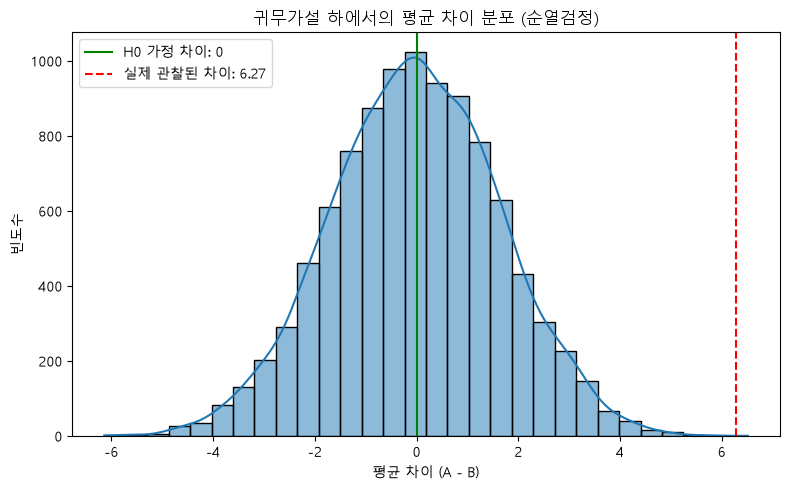

In [24]:
# [문제 3] Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

observed_diff = group_a.mean() - group_b.mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(permuted_diffs, bins=30, kde=True, ax=ax)

ax.axvline(0, color="green", linestyle="-", label="H0 가정 차이: 0")
ax.axvline(observed_diff, color="red", linestyle="--", label=f"실제 관찰된 차이: {observed_diff:.2f}")

ax.set_title("귀무가설 하에서의 평균 차이 분포 (순열검정)")
ax.set_xlabel("평균 차이 (A - B)")
ax.set_ylabel("빈도수")
ax.legend()
plt.tight_layout()
plt.show()

🧠 데이터를 어떻게 읽을까요?

정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요?
▸ 정규성 검정의 경우 그룹 A: 통계량=0.9876, p-값=0.8766, 그룹 B: 통계량=0.9866, p-값=0.8366을 보았을 때 p-값이 0.05보다 크기 때문에 각각의 효과는 사실상 없다고 보여진다. 귀무가설을 기각하지 않기 때문에 등분산성 검정을 진행하였고 p-값: 0.0150 두 그룹간의 분산이 다르기 때문에 이표본 t-검정을 사용하는 두 그룹간의 분산이 같다는 조건이 성립되지 않아 사용하기에 문제 있다.

Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요?
▸ 가설검정의 경우 귀무가설을 기준으로 하기 때문에 두 그룹간의 차이가 없는 즉 0이 가운데에 위치하게 된다.

실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요?
▸ 두 방식의 효과가 같다고 가정하였을 때 실제 관찰된 평균의 차이는 정상적으로 나타날 수 있는 범위를 크게 벗어났다.

이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요?
▸ 귀무가설 즉 두 방식의 효과가 같다는 기준에 드물게 나타나는 것으로 그래프에서 확인할 수 있다.

통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요?
▸ 교육 기업에서는 그룹 B의 방법 보다는 그룹 A의 방법을 적극적으로 활용하여 학생들의 학업 능률을 올릴 수 있다.

관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60


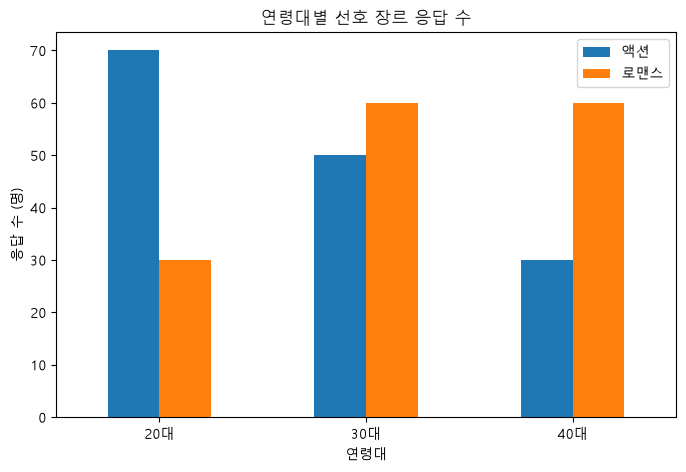

In [25]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 연령대(20대, 30대, 40대)에 따라 영화 장르(액션, 로맨스)의 차이가 없다.
# H₁ (대립가설): 연령대(20대, 30대, 40대)에 따라 영화 장르(액션, 로맨스)의 차이가 있다.

In [26]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.

chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"p-값: {p_value:.4f}")
print(f"자유도: {dof}")
print()
print("=== 관측 빈도 ===")
print(observed)
print()
print("=== 기대 빈도 ===")
print(expected_df.round(2))

카이제곱 통계량: 26.9091
p-값: 0.0000
자유도: 2

=== 관측 빈도 ===
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60

=== 기대 빈도 ===
       액션   로맨스
20대  50.0  50.0
30대  55.0  55.0
40대  45.0  45.0


In [27]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
# 힌트 1: 전체 비율(observed.sum(axis=0) / 전체, observed.sum(axis=1) / 전체)을 확률로 사용
# 힌트 2: np.random.choice 로 300명의 연령대와 장르를 각각 독립적으로 생성
# 힌트 3: pd.crosstab 으로 분할표 생성 후 stats.chi2_contingency 로 통계량 계산

np.random.seed(42)

total = observed.values.sum()
age_probs = observed.sum(axis=1) / total       # 연령대별 비율 (마진 확률)
genre_probs = observed.sum(axis=0) / total      # 장르별 비율 (마진 확률)

n_customers = 300
n_simulations = 5000

simulated_chi2 = []   # 결과를 쌓아둘 빈 리스트

for i in range(n_simulations):
    # 연령대와 장르를 각각 '독립적으로' 무작위 생성
    sim_ages = np.random.choice(age_probs.index, size=n_customers, p=age_probs.values)
    sim_genres = np.random.choice(genre_probs.index, size=n_customers, p=genre_probs.values)
    
    sim_table = pd.crosstab(sim_ages, sim_genres)
    chi2_stat, _, _, _ = stats.chi2_contingency(sim_table)
    
    simulated_chi2.append(chi2_stat)

print(f"총 {len(simulated_chi2)}개의 시뮬레이션 카이제곱 값이 저장되었습니다")
print([round(x, 3) for x in simulated_chi2[:5]])

총 5000개의 시뮬레이션 카이제곱 값이 저장되었습니다
[np.float64(3.867), np.float64(3.231), np.float64(4.303), np.float64(0.099), np.float64(0.25)]


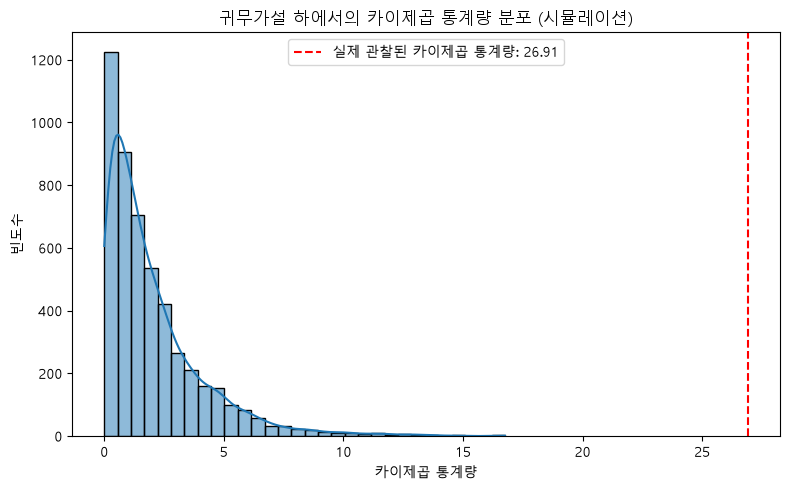

In [28]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.

observed_chi2, _, _, _ = stats.chi2_contingency(observed)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(simulated_chi2, bins=30, kde=True, ax=ax)

ax.axvline(observed_chi2, color="red", linestyle="--", 
           label=f"실제 관찰된 카이제곱 통계량: {observed_chi2:.2f}")

ax.set_title("귀무가설 하에서의 카이제곱 통계량 분포 (시뮬레이션)")
ax.set_xlabel("카이제곱 통계량")
ax.set_ylabel("빈도수")
ax.legend()
plt.tight_layout()
plt.show()

🧠 데이터를 어떻게 읽을까요?
'기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요?
▸ 기대 빈도는 귀무가설의 차이가 없다는 기준에 따른 빈도이고 관측 빈도는 실제 데이터의 빈도를 의미한다. 그래서 두 그룹간의 차이가 클 수록 카이제곱 통계량은 증가한다.

Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요?
▸카이제곱 통계량은 26.91로 극단적인 값에 해당한다.

유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요?
▸ 유의수준 0.05 기준 매우 극단적인 값에 해당하여 연령대와 선호 장르 사이의 차이가 있다는 가설이 통계적으로 유의하다고 볼 수 있다.

이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?
▸ 우선 해당 영화관의 주요 연령층을 별도로 조사해서 20대, 30대, 40대 중에서 가장 많은 연령대가 선호하는 영화의 관 수를 늘리고 각 연령대별로 선호하지 않는 관 수는 최소화한다.

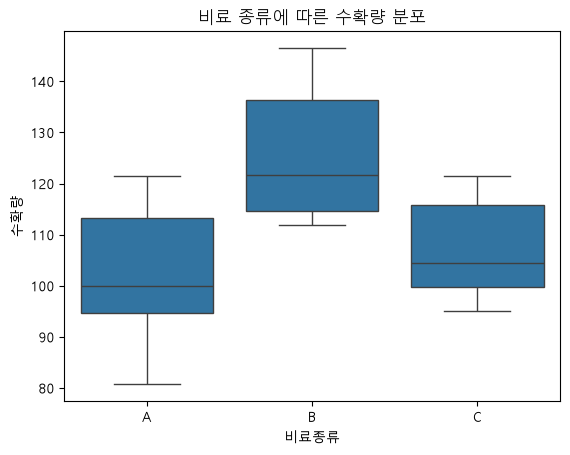

In [29]:
# 데이터 생성 (비료 종류별 수확량)
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9, size=10)

# 데이터프레임으로 변환 (사후분석을 위해)
df = pd.DataFrame({'수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
                   '비료종류': ['A']*10 + ['B']*10 + ['C']*10})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

In [32]:
# [문제 5] Q1. 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.
# H₀: 세 비료의 평균 수확량은 모두 같다.
# H₁: 적어도 하나 이상의 비료 평균 수확량은 다르다.

f_stat, p_value = stats.f_oneway(fertilizer_a, fertilizer_b, fertilizer_c)

print(f"F-통계량: {f_stat:.4f}")
print(f"p-값: {p_value:.4f}")

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(df["수확량"], df["비료종류"], alpha=0.05)
print(tukey_result)

F-통계량: 10.3455
p-값: 0.0005
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  23.6754 0.0006  10.0402 37.3106   True
     A      C   4.8429 0.6569  -8.7923 18.4781  False
     B      C -18.8325 0.0054 -32.4677 -5.1972   True
-----------------------------------------------------


In [33]:
# [문제 5] Q2. ANOVA의 p-값이 유의수준 0.05보다 작을 경우에만
# Tukey's HSD 사후분석을 수행하고 결과를 출력해봅시다.
# 힌트: pairwise_tukeyhsd(endog=수확량, groups=비료종류, alpha=0.05)

alpha = 0.05

if p_value < alpha:
    print(f"ANOVA p-value({p_value:.4f}) < {alpha}: 유의미한 차이가 있으므로 사후분석을 진행합니다.\n")
    
    tukey_result = pairwise_tukeyhsd(endog=df["수확량"], groups=df["비료종류"], alpha=alpha)
    print(tukey_result)
else:
    print(f"ANOVA p-value({p_value:.4f}) >= {alpha}: 그룹 간 유의미한 차이가 없어 사후분석이 필요하지 않습니다.")

ANOVA p-value(0.0005) < 0.05: 유의미한 차이가 있으므로 사후분석을 진행합니다.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B  23.6754 0.0006  10.0402 37.3106   True
     A      C   4.8429 0.6569  -8.7923 18.4781  False
     B      C -18.8325 0.0054 -32.4677 -5.1972   True
-----------------------------------------------------


In [34]:
# [문제 5] Q3. H₀가 사실(세 그룹의 평균이 모두 같다)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 모든 데이터를 합친 평균과 표준편차를 가진 H₀ 모집단에서 10개씩 3개의 가상 그룹을 생성하고,
# 이 가상 그룹들로 ANOVA를 수행하여 F-통계량을 리스트에 저장해보세요.

np.random.seed(42)

all_data = np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c])
pooled_mean = all_data.mean()
pooled_std = all_data.std(ddof=1)

n_simulations = 5000
simulated_f_stats = []   # 결과를 쌓아둘 빈 리스트

for i in range(n_simulations):
    sim_a = np.random.normal(loc=pooled_mean, scale=pooled_std, size=10)
    sim_b = np.random.normal(loc=pooled_mean, scale=pooled_std, size=10)
    sim_c = np.random.normal(loc=pooled_mean, scale=pooled_std, size=10)
    
    f_stat_sim, _ = stats.f_oneway(sim_a, sim_b, sim_c)
    simulated_f_stats.append(f_stat_sim)

print(f"총 {len(simulated_f_stats)}개의 시뮬레이션 F-통계량이 저장되었습니다")
print([round(x, 3) for x in simulated_f_stats[:5]])

총 5000개의 시뮬레이션 F-통계량이 저장되었습니다
[np.float64(6.569), np.float64(0.892), np.float64(0.058), np.float64(0.244), np.float64(0.314)]


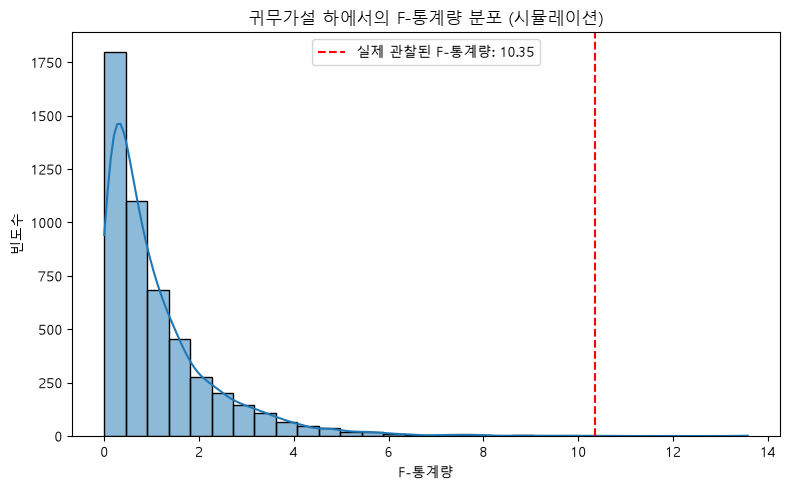

In [35]:
# [문제 5] Q4. 시뮬레이션으로 얻은 F-통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 F-통계량을 세로선으로 함께 표시해 봅시다.

observed_f_stat, _ = stats.f_oneway(fertilizer_a, fertilizer_b, fertilizer_c)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(simulated_f_stats, bins=30, kde=True, ax=ax)

ax.axvline(observed_f_stat, color="red", linestyle="--", 
           label=f"실제 관찰된 F-통계량: {observed_f_stat:.2f}")

ax.set_title("귀무가설 하에서의 F-통계량 분포 (시뮬레이션)")
ax.set_xlabel("F-통계량")
ax.set_ylabel("빈도수")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# [문제 5] Q5. 분석 결과를 바탕으로 연구소에 어떤 비료를 추천하시겠습니까?
# 여기에 의견을 작성해주세요.

🧠 데이터를 어떻게 읽을까요?
ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?
▸ 분산분석의 검정으로 P-값이 0.0005에 해당하여 세 비료가 모두 동일한 효과를 가지지 않고 적어도 하나는 다르다는 결과를 얻었다.

Tukey's HSD 결과표의 reject 열에서 True로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?
▸ 사후분석의 결과표로 A/B, B/C가 True로 표시되었고 B가 A와 C와 다른 효과를 가지는 것을 의미한다.

meandiff 열의 값은 어떤 정보를 주나요? 신뢰구간(lower, upper)이 0을 포함하는지 여부는 무엇을 뜻할까요?
▸ meandiff는 두 그룹 평균의 **차이(그룹1 평균 - 그룹2 평균)**를 나타내므로 A/B, B/C는 신뢰구간이 0을 포함하지 않기 때문에 귀무가설을 기준으로 드물게 나타나는 결과에 해당하고 A/C는 0을 포함하여 흔하게 나타난다.

그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?
▸ 표본의 크기가 적어서 이게 우연의 일치로 나타난 것인지 실제 통계젹으로 유의한지 명확하지 않아 표본의 개수를 30개 이상으로 늘려 추가 분석을 진행하는 것이 좋다.